# counting_defects_with_efds_.ipynb

Code in this notebook comes from a [Gemini response](https://gemini.google.com/share/082fd52ef82e) to this prompt:
```
How can I estimate the number of defects on a contour using elliptic fourier descriptors? Please provide a Jupyter notebook which shows me how develop a pipeline to do this using sklearn.
```

In [1]:

# Install necessary libraries if you haven't
# !pip install pyefd scikit-learn matplotlib numpy opencv-python

import numpy as np
import matplotlib.pyplot as plt
from pyefd import elliptic_fourier_descriptors, reconstruct_contour
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

from sim_palm import generate_palm_with_cuts
from icecream import ic
import cv2
from time import sleep

# First code example from Gemini

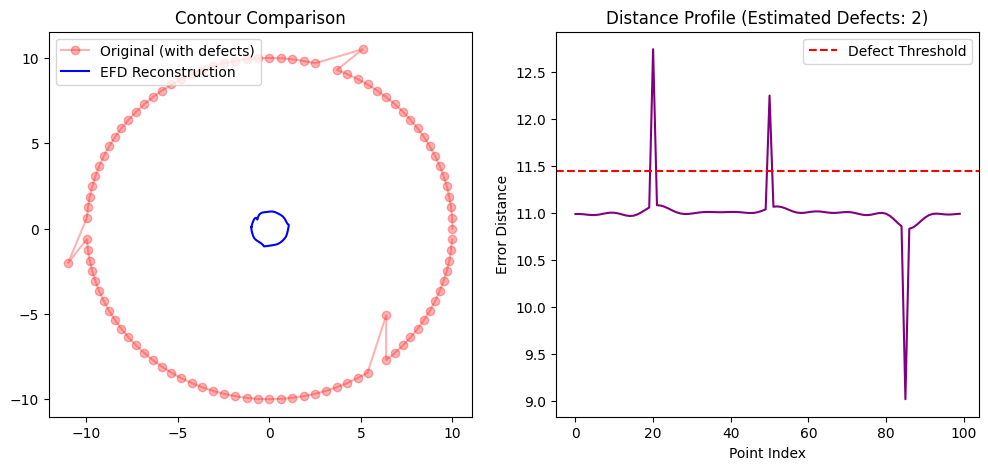

Total estimated distinct defects: 2


In [2]:

# 1. Generate a Synthetic Shape with "Defects"
def generate_dirty_circle(points=100):
    t = np.linspace(0, 2 * np.pi, points, endpoint=False)
    # A base circle
    x = 10 * np.cos(t)
    y = 10 * np.sin(t)
    
    # Add 3 specific "defects" (local spikes)
    contour = np.stack((x, y), axis=1)
    contour[20] += [2, 1] 
    contour[50] -= [1, 2]
    contour[85] += [0.5, 3]
    return contour

# 2. Extract Features
contour = generate_dirty_circle()

# Calculate EFD coefficients
# order=10 captures general shape; higher captures noise/defects
coeffs = elliptic_fourier_descriptors(contour, order=10, normalize=True)

# 3. Reconstruct the "Smooth" Version
# This acts as our "ideal" template derived from the noisy data
reconstructed = reconstruct_contour(coeffs, num_points=100)

# 4. Calculate Point-wise Error (The "Defect" Score)
# We find the Euclidean distance between the original and smooth contour
distances = np.sqrt(np.sum((contour - reconstructed)**2, axis=1))

# 5. Thresholding & Clustering with SKLearn
# We use DBSCAN to group high-error points into distinct "defect" zones
threshold = np.mean(distances) + 1.5 * np.std(distances)
defect_indices = np.where(distances > threshold)[0]
defect_coords = contour[defect_indices]

if len(defect_coords) > 0:
    # Cluster the points to count how many distinct defects exist
    clustering = DBSCAN(eps=2.0, min_samples=1).fit(defect_coords)
    num_defects = len(set(clustering.labels_))
else:
    num_defects = 0

# 6. Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(contour[:, 0], contour[:, 1], 'ro-', label='Original (with defects)', alpha=0.3)
ax[0].plot(reconstructed[:, 0], reconstructed[:, 1], 'b-', label='EFD Reconstruction')
ax[0].legend()
ax[0].set_title("Contour Comparison")

ax[1].plot(distances, color='purple')
ax[1].axhline(y=threshold, color='r', linestyle='--', label='Defect Threshold')
ax[1].set_title(f"Distance Profile (Estimated Defects: {num_defects})")
ax[1].set_xlabel("Point Index")
ax[1].set_ylabel("Error Distance")
ax[1].legend()

plt.show()

print(f"Total estimated distinct defects: {num_defects}")

# Improved code example from Gemini

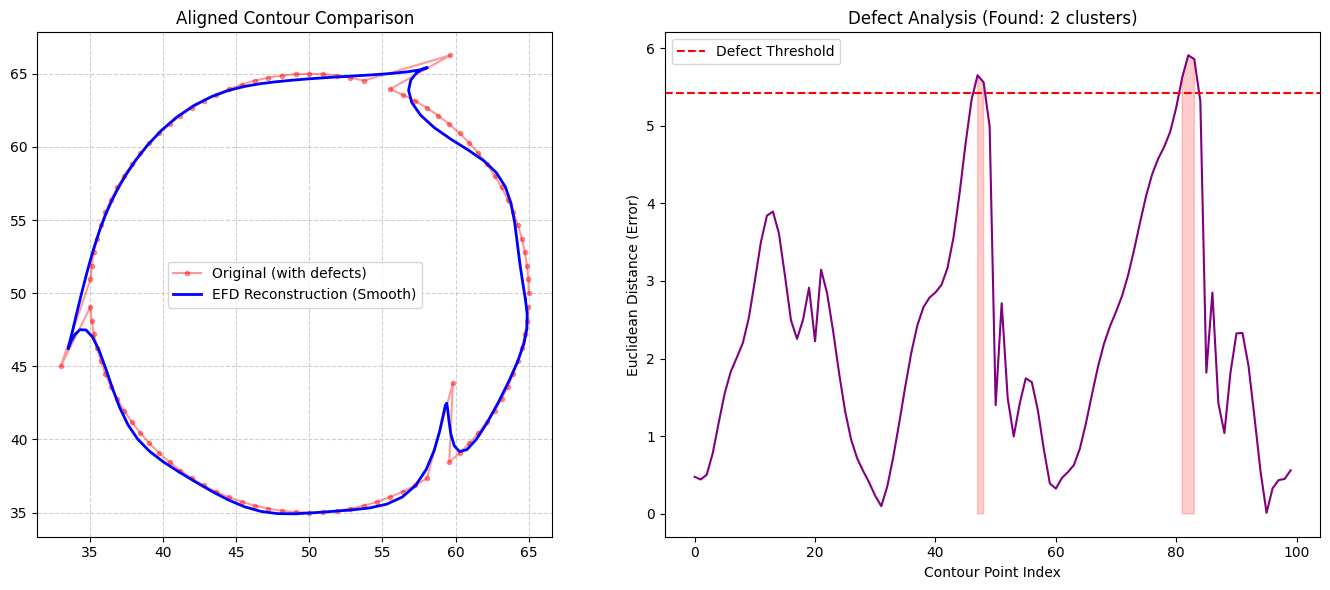

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from pyefd import elliptic_fourier_descriptors, reconstruct_contour
# from sklearn.cluster import DBSCAN

# 1. Generate a Synthetic Shape with "Defects"
def generate_dirty_circle(points=100):
    t = np.linspace(0, 2 * np.pi, points, endpoint=False)
    x = 15 * np.cos(t) + 50  # Offset to 50,50
    y = 15 * np.sin(t) + 50
    
    contour = np.stack((x, y), axis=1)
    # Adding prominent defects
    contour[20] += [5, 2] 
    contour[50] -= [2, 5]
    contour[85] += [1, 6]
    return contour

contour = generate_dirty_circle()

# 2. Extract Features WITHOUT Normalization for direct comparison
# We keep normalize=False so the reconstruction stays in original pixels/units
# We capture the centroid to ensure we can reconstruct at the right spot
coeffs = elliptic_fourier_descriptors(contour, order=10, normalize=False)

# 3. Reconstruct the "Smooth" Version
# This will now be on the same scale as the original
reconstructed = reconstruct_contour(coeffs, num_points=100)

# Calculate the centroid of the original to shift the reconstruction back
# EFD reconstruction is often centered at (0,0) or uses the DC component (coeffs[0])
centroid = np.mean(contour, axis=0)
reconstructed += centroid

# 4. Calculate Point-wise Error
distances = np.sqrt(np.sum((contour - reconstructed)**2, axis=1))

# 5. Thresholding & Clustering (SKLearn)
threshold = np.mean(distances) + 2 * np.std(distances)
defect_indices = np.where(distances > threshold)[0]
defect_coords = contour[defect_indices]

num_defects = 0
if len(defect_coords) > 0:
    clustering = DBSCAN(eps=3.0, min_samples=1).fit(defect_coords)
    num_defects = len(set(clustering.labels_))

# 6. Corrected Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Overlaid Contours with Fixed Aspect Ratio
ax[0].plot(contour[:, 0], contour[:, 1], 'ro-', label='Original (with defects)', alpha=0.4, markersize=3)
ax[0].plot(reconstructed[:, 0], reconstructed[:, 1], 'b-', linewidth=2, label='EFD Reconstruction (Smooth)')
ax[0].set_aspect('equal') # Vital for geometric shapes
ax[0].set_title("Aligned Contour Comparison")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Distance Profile
ax[1].plot(distances, color='purple', linewidth=1.5)
ax[1].axhline(y=threshold, color='r', linestyle='--', label='Defect Threshold')
ax[1].fill_between(range(len(distances)), 0, distances, where=(distances > threshold), color='red', alpha=0.2)
ax[1].set_title(f"Defect Analysis (Found: {num_defects} clusters)")
ax[1].set_xlabel("Contour Point Index")
ax[1].set_ylabel("Euclidean Distance (Error)")
ax[1].legend()

plt.tight_layout()
plt.show()

# Experimental code

Point added to close contour.


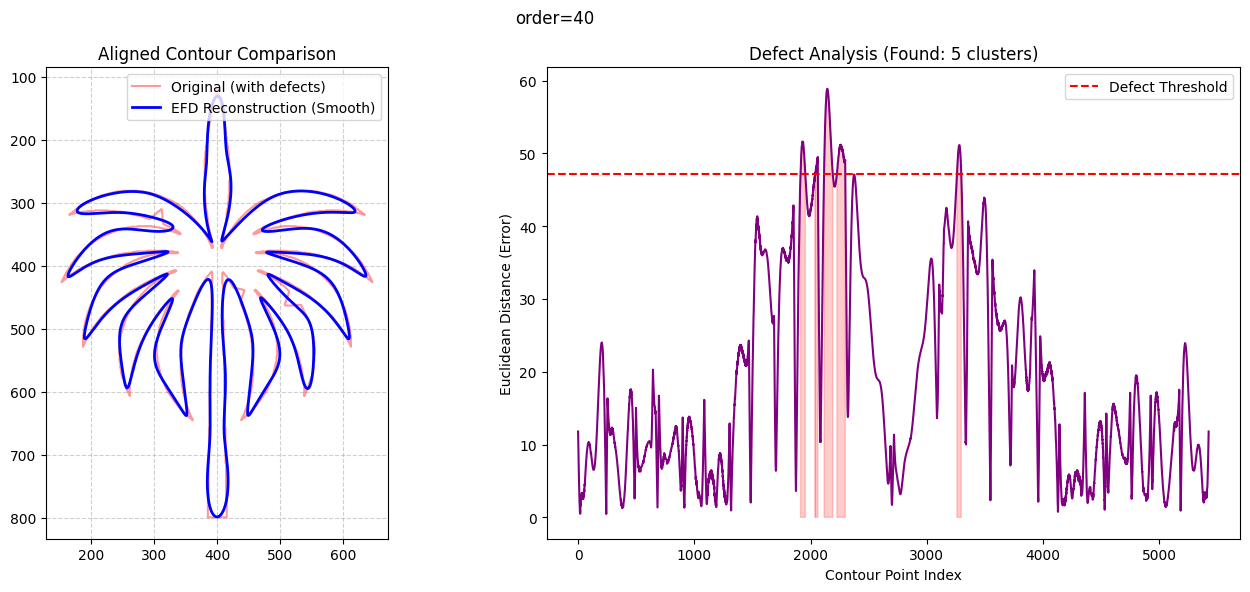

In [4]:
# 1. Generate a Synthetic Shape with "Defects"
def generate_dirty_circle(points=100):
    t = np.linspace(0, 2 * np.pi, points, endpoint=False)
    x = 15 * np.cos(t) + 50  # Offset to 50,50
    y = 15 * np.sin(t) + 50
    
    contour = np.stack((x, y), axis=1)
    # Adding prominent defects
    contour[20] += [5, 2] 
    contour[50] -= [2, 5]
    contour[85] += [1, 6]
    return contour


def count_cuts(contour, order=10):

    # 2. Extract Features WITHOUT Normalization for direct comparison
    # We keep normalize=False so the reconstruction stays in original pixels/units
    # We capture the centroid to ensure we can reconstruct at the right spot
    coeffs = elliptic_fourier_descriptors(contour, order, normalize=False)

    # 3. Reconstruct the "Smooth" Version
    # This will now be on the same scale as the original
    reconstructed = reconstruct_contour(coeffs, num_points=contour.shape[0])

    # Calculate the centroid of the original to shift the reconstruction back
    # EFD reconstruction is often centered at (0,0) or uses the DC component (coeffs[0])
    centroid = np.mean(contour, axis=0)
    reconstructed += centroid

    # 4. Calculate Point-wise Error
    distances = np.sqrt(np.sum((contour - reconstructed)**2, axis=1))

    # 5. Thresholding & Clustering (SKLearn)
    threshold = np.mean(distances) + 2 * np.std(distances)
    defect_indices = np.where(distances > threshold)[0]
    defect_coords = contour[defect_indices]

    num_defects = 0
    if len(defect_coords) > 0:
        clustering = DBSCAN(eps=3.0, min_samples=1).fit(defect_coords)
        num_defects = len(set(clustering.labels_))

    # 6. Corrected Visualization
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))  
    fig.suptitle(f'{order=}')

    # Plot 1: Overlaid Contours with Fixed Aspect Ratio
    ax[0].plot(contour[:, 0], contour[:, 1], 'r-', label='Original (with defects)', alpha=0.4, markersize=3)
    ax[0].plot(reconstructed[:, 0], reconstructed[:, 1], 'b-', linewidth=2, label='EFD Reconstruction (Smooth)')
    ax[0].set_aspect('equal') # Vital for geometric shapes
    ax[0].set_title("Aligned Contour Comparison")
    ax[0].legend()
    ax[0].grid(True, linestyle='--', alpha=0.6)
    ax[0].invert_yaxis()

    # Plot 2: Distance Profile
    ax[1].plot(distances, color='purple', linewidth=1.5)
    ax[1].axhline(y=threshold, color='r', linestyle='--', label='Defect Threshold')
    ax[1].fill_between(range(len(distances)), 0, distances, where=(distances > threshold), color='red', alpha=0.2)
    ax[1].set_title(f"Defect Analysis (Found: {num_defects} clusters)")
    ax[1].set_xlabel("Contour Point Index")
    ax[1].set_ylabel("Euclidean Distance (Error)")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


# MAIN 

# contour = generate_dirty_circle()
contour, mask = generate_palm_with_cuts(3)
for order in [40]:   
    count_cuts(contour, order=order)


# Experimental code

After looking at the above figure, it appears that one way to go is to:

- convert the original contour and reconstructed contour to masks
- then, find all `True` pixels in the reconstruction mask which are `False` in the original mask

The difference mask can be calculated using:
```python
diff_mask = reconstructed_mask & ~original_mask
```

## parameters

## Inputs
- image
- tree contour(s)

## Outputs
- vcut contours


# Gemini prompt

I have a python function which takes an image and contours as input and returns a single `contours` object as output. 
I want to add a flag to the function arguments called RETURN_PLOT_DATA. 
When RETURN_PLOT_DATA is True, an additional object named `plot_data` will be returned.
Please provide example python code which implements my idea.

[response](https://gemini.google.com/share/d7d613dfe423)

In [5]:
def process_contours(image, contours, return_plot_data=False):
    """
    Processes image contours and optionally returns data for plotting.
    """
    # 1. Your existing logic to process contours
    # For this example, let's just assume we're 'filtering' them
    processed_contours = [cnt for cnt in contours if len(cnt) > 10]
    
    # 2. Conditional logic to generate plot_data
    # This might be coordinates, bounding boxes, or metadata
    if return_plot_data:
        plot_data = {
            "count": len(processed_contours),
            "mean_area": np.mean([len(c) for c in processed_contours]) if processed_contours else 0,
            "status": "Success"
        }
        if return_plot_data:
            return processed_contours, plot_data
    
    return processed_contours

# --- Examples of Usage ---

contour, mask = generate_palm_with_cuts(1)
img_data = mask
raw_contours = [contour]

# Case A: Standard usage (returns only contours)
ic('Case 1')
contours_only = process_contours(img_data, raw_contours)
ic(contours_only);

# Case B: Plotting usage (returns a tuple)
ic('Case 2')
contours, metadata = process_contours(img_data, raw_contours, return_plot_data=True)
ic(contours, metadata)

print(f"Processed {metadata['count']} contours.")

Point added to close contour.
Processed 1 contours.


ic| 'Case 1'
ic| contours_only: [array([[400, 119],
                          [400, 120],
                          [399, 121],
                          ...,
                          [400, 121],
                          [400, 120],
                          [400, 119]], shape=(5371, 2), dtype=int32)]
ic| 'Case 2'
ic| contours: [array([[400, 119],
                     [400, 120],
                     [399, 121],
                     ...,
                     [400, 121],
                     [400, 120],
                     [400, 119]], shape=(5371, 2), dtype=int32)]
    metadata: {'count': 1, 'mean_area': np.float64(5371.0), 'status': 'Success'}


Point added to close contour.


ic| 'USE CASE 1 - without plots'
ic| ncuts_detected: 3
ic| 'USE CASE 2 - with plots (return_plot_data=True)'


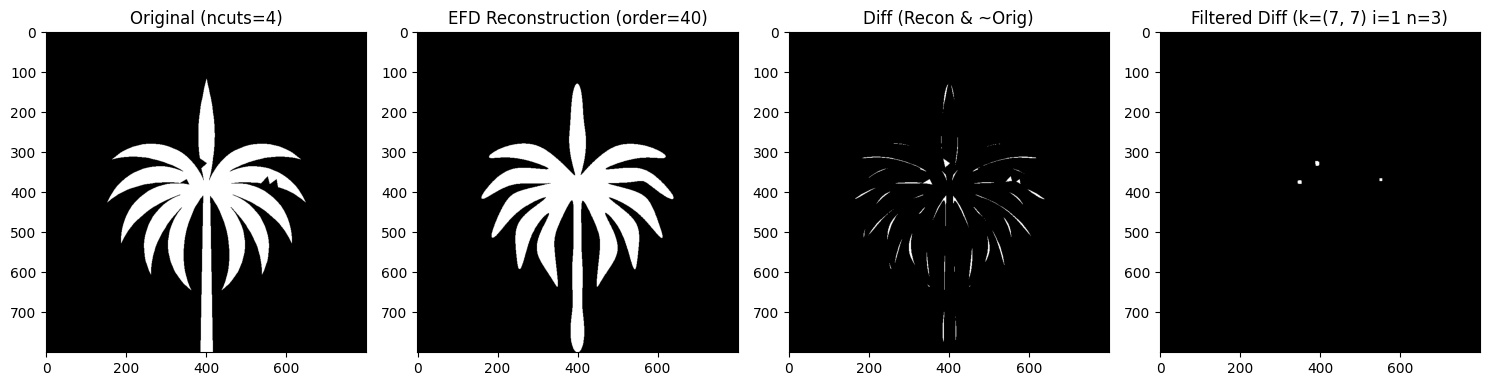

In [17]:
def efd_find_cuts(original_contour, original_mask, order=40, ksize=(7,7), iterations=1, return_plot_data=False):
    """ 
    This function was created to detect and locate defects in binary masks 
    of coconut palms, such as v-shaped cuts caused by coconut rhinoceros beetles.
    
    Synthetic contours and masks for testing be provided by the generate_palms_with_cuts function. 
    
    Elliptic Fourier descriptors are calculated and used to reconstruct a "smoothed version" of the original mask.
    Cuts are apparent in the difference between the smoothed mask and the original mask.
    
    In the final step, noise is removed filtered out using a morphological operation called "opening". 
    
    Required arguments:
        original_contour    binary mask of a coconut palm
        original_mask       a binary mask (filled original_contour)
        
    Arguments with defaults:
        order               an EFD parameter which determines the size of the descriptor 
        ksize               a tuple defining the size of the kernel used by the morphological operation
        iterations          number of times the morphological operation is applied to a mask
        return_plot_data    a binary flag which determines if plot_data are calculated and returned
        
    Return values:
        contours            a tuple containing contours (each contour is a numpy array of points; dtype=int32)
        plot_data           a dict containing binary masks for visualization  
    """

    ic.disable()

    # original_contour, original_mask = generate_palm_with_cuts(ncuts)
    # ic(original_contour)
    # ic(original_mask)
    # ic(np.sum(original_mask))

    # calc EFDs
    coeffs = elliptic_fourier_descriptors(original_contour, order, normalize=False)

    # reconstruct contour
    reconstructed_contour = reconstruct_contour(coeffs, num_points=original_contour.shape[0])

    # Calculate the centroid of the original to shift the reconstruction back
    # EFD reconstruction is often centered at (0,0) or uses the DC component (coeffs[0])
    centroid = np.mean(original_contour, axis=0)
    ic(centroid)
    reconstructed_contour += centroid
    reconstructed_contour = reconstructed_contour.astype(np.int32)
    ic(reconstructed_contour)

    reconstructed_mask = cv2.fillPoly(np.zeros_like(original_mask), pts=[reconstructed_contour], color=1)
    ic(reconstructed_mask)
    ic(np.sum(reconstructed_mask))

    # Calculate the difference mask
    diff_mask = reconstructed_mask & ~original_mask
    ic(diff_mask)

    # Create clean_mask
    # Define kernel (size depends on how thick the "thin" features are)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=ksize)
    # Apply Opening
    clean_mask = cv2.morphologyEx(diff_mask, cv2.MORPH_OPEN, kernel, iterations=iterations)
    
    # get vcut contours
    contours, _ = cv2.findContours(image=clean_mask, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_NONE)
    ic.enable()
    
    if return_plot_data:
        plot_data = {
            'original_mask': original_mask, 
            'reconstructed_mask': reconstructed_mask,
            'diff_mask': diff_mask, 
            'clean_mask': clean_mask
        }
        return contours, plot_data
    
    return contours

    
# MAIN

ncuts = 4
order = 40
ksize = (7,7)
iterations=1

contour, mask = generate_palm_with_cuts(ncuts)

ic('USE CASE 1 - without plots')
vcut_contours = efd_find_cuts(
    original_contour=contour, 
    original_mask=mask, 
    order=order,
    ksize=ksize,
    iterations=iterations)
ncuts_detected = len(vcut_contours)
ic(ncuts_detected);

ic('USE CASE 2 - with plots (return_plot_data=True)')
vcut_contours, plot_data = efd_find_cuts(
    original_contour=contour, 
    original_mask=mask, 
    order=order,
    ksize=ksize,
    iterations=iterations,
    return_plot_data=True)
ncuts_detected = len(vcut_contours)

# Plot example:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
masks = [
    plot_data['original_mask'], 
    plot_data['reconstructed_mask'], 
    plot_data['diff_mask'], 
    plot_data['clean_mask']
    ]
titles = [
    f'Original ({ncuts=})', 
    f'EFD Reconstruction ({order=})', 
    'Diff (Recon & ~Orig)', 
    f'Filtered Diff (k={ksize} i={iterations} n={ncuts_detected})']
for ax, mask, title in zip(axes, masks, titles):
    ax.imshow(mask, cmap='gray')
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [16]:
ic(vcut_contours);

ic| vcut_contours: (array([[[475, 439]],
                   
                          [[475, 440]],
                   
                          [[475, 441]],
                   
                          [[475, 442]],
                   
                          [[475, 443]],
                   
                          [[475, 444]],
                   
                          [[475, 445]],
                   
                          [[475, 446]],
                   
                          [[476, 447]],
                   
                          [[477, 447]],
                   
                          [[478, 447]],
                   
                          [[479, 447]],
                   
                          [[480, 447]],
                   
                          [[481, 447]],
                   
                          [[482, 447]],
                   
                          [[482, 446]],
                   
                          [[482, 445]],